<a href="https://colab.research.google.com/github/Divyanshiii-23/BRAINS/blob/main/BRAINS_Bayesian_Portfolio_Engine_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BRAINS: Bayesian Ranking and Analysis of Investment Strategies

**An automated investment engine for portfolio optimization, return forecasting, and risk-adjusted performance evaluation.**

Pipeline:
1. Universe & price data
2. Fama–French size (SMB) and value (HML) factor exposures
3. Financial-metric extraction (scraping + fundamentals)
4. NLP sentiment signals from news headlines
5. Black–Litterman model — blend market equilibrium returns with factor + sentiment-derived investor views
6. Mean-variance portfolio optimization on the Black–Litterman posterior
7. Backtest + risk-adjusted performance evaluation (Sharpe, Sortino, max drawdown, diversification)



## 0. Setup

In [ ]:
!pip install -q yfinance pandas_datareader PyPortfolioOpt vaderSentiment feedparser beautifulsoup4 lxml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 6.9 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import feedparser
import matplotlib.pyplot as plt

import yfinance as yf
import pandas_datareader.data as web

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pypfopt import EfficientFrontier, risk_models, expected_returns, black_litterman
from pypfopt.black_litterman import BlackLittermanModel

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.random.seed(42)


## 1. Configuration

Edit this cell to change the universe, dates, or risk parameters. Default universe is a liquid NSE large-cap basket (swap in S&P 500 tickers like `"AAPL"` if you'd rather run it on US equities — no other code changes needed).

In [ ]:
# --- Universe -----------------------------------------------------------
UNIVERSE = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS",
    "HINDUNILVR.NS", "ITC.NS", "LT.NS", "SBIN.NS", "BHARTIARTL.NS",
    "KOTAKBANK.NS", "AXISBANK.NS", "MARUTI.NS", "SUNPHARMA.NS", "TITAN.NS",
]
BENCHMARK = "^NSEI"          # Nifty 50 index, proxy for the market portfolio
NEWS_QUERY_SUFFIX = " stock NSE"   # appended to company name for news search

# --- Dates ----------------------------------------------------------------
START_DATE = "2020-01-01"
END_DATE   = "2025-12-31"
BACKTEST_SPLIT = "2024-01-01"      # data before this trains/estimates, after this is the backtest window

# --- Risk / model parameters ----------------------------------------------
RISK_FREE_RATE = 0.07              # annualized, India ~7%
DELTA = 2.5                        # market risk-aversion coefficient for BL equilibrium returns
TAU = 0.05                         # BL uncertainty scaling on the prior
MAX_WEIGHT = 0.20                  # per-stock cap in the optimizer


### A note on look-ahead bias

Everything used to *build* the portfolio (covariance matrix, Fama-French betas, Black-Litterman views) must only see data from **before** `BACKTEST_SPLIT`. Everything used to *evaluate* it (the backtest returns) must only see data from **on or after** `BACKTEST_SPLIT`. The cells below enforce this by working off `train_prices`/`train_returns` (pre-split) for every estimation step, and `backtest_returns` (post-split) only in Section 8.

**Remaining, disclosed limitation:** market cap, P/B ratios (Section 3 proxy factors), and the scraped fundamentals/news sentiment (Sections 4–5) are pulled as of *today* via `yfinance`/`screener.in`/Google News — there's no free historical snapshot for these as of `BACKTEST_SPLIT`. So the return-forecasting engine is not a fully point-in-time backtest; it's a train/test split on price-derived quantities (covariance, factor betas) with current-day fundamentals and sentiment layered on top.

## 2. Price Data

In [ ]:
def download_prices(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)["Close"]
    raw = raw.dropna(axis=1, how="all")   # drop tickers that failed entirely
    raw = raw.ffill().dropna()
    return raw

prices = download_prices(UNIVERSE, START_DATE, END_DATE)
bench_prices = download_prices([BENCHMARK], START_DATE, END_DATE)[BENCHMARK]

# keep universe in sync with whatever actually downloaded
UNIVERSE = list(prices.columns)

daily_returns = prices.pct_change().dropna()

# --- Train/test split: everything estimated for the model must stop here ---
train_end = pd.Timestamp(BACKTEST_SPLIT) - pd.Timedelta(days=1)
train_prices = prices.loc[:train_end]
train_returns = daily_returns.loc[:train_end]

print(f"Downloaded {prices.shape[1]} tickers, {prices.shape[0]} trading days total")
print(f"Estimation window: {train_prices.index.min().date()} -> {train_prices.index.max().date()} ({len(train_prices)} days)")
print(f"Backtest window:   {BACKTEST_SPLIT} -> {prices.index.max().date()}")
prices.tail()


Downloaded 15 tickers, 1486 trading days total
Estimation window: 2020-01-01 -> 2023-12-29 (992 days)
Backtest window:   2024-01-01 -> 2025-12-30


Ticker,AXISBANK.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,MARUTI.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS
Date,,,,,,,,,,,,,,,
2025-12-23,"1,224.0560","2,096.5146",980.3849,"2,279.4148","1,351.6052","1,632.9637",388.4067,431.7945,"4,019.5398","16,420.0918","1,563.4711",954.6917,"1,740.0074","3,189.9224","3,912.9604"
2025-12-24,"1,225.3550","2,097.3049",980.9752,"2,259.2202","1,348.4321","1,628.1675",387.6916,431.9942,"4,014.3901","16,536.9180","1,551.0287",951.7939,"1,721.2786","3,198.5959","3,896.5144"
2025-12-26,"1,227.2534","2,079.2322",975.9582,"2,262.3879","1,339.1106","1,621.0221",385.3555,432.0940,"4,008.1509","16,430.9824","1,552.0240",949.1907,"1,703.9369","3,161.0110","3,978.9438"
2025-12-29,"1,231.0505","2,055.7283",975.5647,"2,270.2085","1,332.0701","1,609.8635",383.8776,430.9760,"3,999.6340","16,377.5195","1,538.4867",947.9629,"1,701.6576","3,133.5444","3,970.6709"
2025-12-30,"1,245.0398","2,073.7019",974.7778,"2,267.1396","1,331.2766","1,587.2528",381.9706,429.7980,"4,012.8054","16,481.4766","1,532.7134",956.2142,"1,704.6305","3,129.0151","3,961.1025"


## 3. Fama–French Size (SMB) and Value (HML) Exposures

Ken French's data library doesn't publish an India-region 3-factor series directly through `pandas_datareader`'s usual keys, so we build proxy SMB/HML factors in-house from the same universe (market-cap sort for size, book-to-market/earnings-yield proxy for value), then regress each stock's excess returns on them to get its factor betas — the standard Fama–French cross-sectional procedure. If you're running the US-ticker version, swap this for the real `pandas_datareader.famafrench` dataset (code shown as a fallback below).

In [ ]:
def try_real_fama_french(start, end):
    """Fallback: pulls the real Fama-French 3-factor series (US/global) if available."""
    try:
        ff = web.DataReader("F-F_Research_Data_Factors_daily", "famafrench", start, end)[0] / 100
        if hasattr(ff.index, "to_timestamp"):
            ff.index = ff.index.to_timestamp()
        else:
            ff.index = pd.to_datetime(ff.index)
        return ff.rename(columns={"Mkt-RF": "MKT_RF"})
    except Exception as e:
        print("Real Fama-French pull failed (expected for non-US tickers):", e)
        return None

ff_real = try_real_fama_french(START_DATE, train_end)   # estimation-window only, consistent with the split

def build_proxy_factors(tickers, prices_window, returns_window):
    """Builds SMB/HML proxy factors from market cap and P/B, sorted the FF way,
    over whatever price/return window is passed in (pass train_prices/train_returns
    to keep this inside the estimation window):
    SMB = avg(return of smallest 1/3 by mkt cap) - avg(return of largest 1/3)
    HML = avg(return of highest 1/3 by book/price) - avg(return of lowest 1/3)

    NOTE: marketCap/priceToBook are pulled live from yfinance -- there's no free
    historical snapshot as of a past `BACKTEST_SPLIT`, so this part is a disclosed
    limitation (see the look-ahead-bias note above), not a fully point-in-time value."""
    mktcap, pb = {}, {}
    for t in tickers:
        try:
            info = yf.Ticker(t).info
            mktcap[t] = info.get("marketCap", np.nan)
            pb_ratio = info.get("priceToBook", np.nan)
            pb[t] = (1 / pb_ratio) if pb_ratio and pb_ratio > 0 else np.nan  # book-to-price
        except Exception:
            mktcap[t] = np.nan
            pb[t] = np.nan

    mktcap = pd.Series(mktcap).dropna()
    pb = pd.Series(pb).dropna()

    size_small = mktcap.nsmallest(max(1, len(mktcap)//3)).index
    size_big   = mktcap.nlargest(max(1, len(mktcap)//3)).index
    val_high   = pb.nlargest(max(1, len(pb)//3)).index      # high book/price = value
    val_low    = pb.nsmallest(max(1, len(pb)//3)).index     # low book/price = growth

    smb = returns_window[size_small].mean(axis=1) - returns_window[size_big].mean(axis=1)
    hml = returns_window[val_high].mean(axis=1) - returns_window[val_low].mean(axis=1)
    mkt = returns_window.mean(axis=1)  # equal-weight universe as market proxy

    factors = pd.DataFrame({"MKT": mkt, "SMB": smb, "HML": hml})
    return factors, mktcap, pb

proxy_factors, mktcap_snapshot, btp_snapshot = build_proxy_factors(UNIVERSE, train_prices, train_returns)
print(f"Proxy factors built over the estimation window only: {proxy_factors.index.min().date()} -> {proxy_factors.index.max().date()}")
proxy_factors.tail()


Proxy factors built over the estimation window only: 2020-01-02 -> 2023-12-29


,MKT,SMB,HML
Date,,,
2023-12-22,0.0055,0.0114,-0.0147
2023-12-26,0.0034,0.0021,0.0032
2023-12-27,0.0093,-0.0059,0.0008
2023-12-28,0.0045,0.0001,-0.0025
2023-12-29,-0.0040,0.0019,-0.0049


In [ ]:
def factor_betas(daily_returns, factors, rf_daily):
    """Rolling-free, full-sample OLS of each stock's excess return on MKT, SMB, HML."""
    betas = {}
    X = factors.copy()
    X["const"] = 1.0
    for t in daily_returns.columns:
        y = (daily_returns[t] - rf_daily).reindex(X.index).dropna()
        Xi = X.reindex(y.index)
        coef, *_ = np.linalg.lstsq(Xi.values, y.values, rcond=None)
        betas[t] = dict(zip(Xi.columns, coef))
    return pd.DataFrame(betas).T

rf_daily = RISK_FREE_RATE / 252
ff_betas = factor_betas(train_returns, proxy_factors, rf_daily)  # estimation window only
ff_betas[["MKT", "SMB", "HML"]]


,MKT,SMB,HML
AXISBANK.NS,1.2103,0.5355,0.7745
BHARTIARTL.NS,1.0726,-0.7544,-0.6262
HDFCBANK.NS,0.8842,-0.3592,0.4024
HINDUNILVR.NS,0.8388,0.1055,-0.4884
ICICIBANK.NS,1.1853,-0.2905,0.4492
INFY.NS,1.0544,-0.1883,-0.4238
ITC.NS,0.7691,0.4216,-0.0338
KOTAKBANK.NS,0.8821,0.4320,0.5537
LT.NS,1.0238,0.0438,0.0362
MARUTI.NS,1.1003,0.6433,0.0010


## 4. Financial-Metric Extraction (web scraping + fundamentals)

In [ ]:
def scrape_screener_metrics(ticker_ns):
    """Scrapes headline valuation ratios from screener.in for an NSE ticker.
    Falls back to yfinance fundamentals if the page structure changes or the
    request fails -- keep this defensive, screener's markup shifts often."""
    symbol = ticker_ns.replace(".NS", "")
    url = f"https://www.screener.in/company/{symbol}/"
    try:
        r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
        soup = BeautifulSoup(r.text, "lxml")
        ratios = {}
        for li in soup.select("#top-ratios li"):
            name = li.select_one(".name")
            value = li.select_one(".value")
            if name and value:
                ratios[name.get_text(strip=True)] = value.get_text(strip=True)
        if not ratios:
            raise ValueError("empty ratio block, page structure likely changed")
        return {"source": "screener.in", **ratios}
    except Exception as e:
        info = yf.Ticker(ticker_ns).info
        return {
            "source": "yfinance_fallback",
            "PE": info.get("trailingPE"),
            "PB": info.get("priceToBook"),
            "ROE": info.get("returnOnEquity"),
            "Market Cap": info.get("marketCap"),
            "error": str(e),
        }

metrics = {t: scrape_screener_metrics(t) for t in UNIVERSE}
metrics_df = pd.DataFrame(metrics).T
metrics_df


,source,Market Cap,Current Price,High / Low,Stock P/E,Book Value,Dividend Yield,ROCE,ROE,Face Value
AXISBANK.NS,screener.in,"₹3,84,601Cr.","₹1,236","₹1,418/1,041",14.9,₹681,0.08%,6.07%,12.7%,₹2.00
BHARTIARTL.NS,screener.in,"₹12,06,979Cr.","₹1,935","₹2,175/1,740",70.0,₹263,1.24%,12.7%,10.7%,₹5.00
HDFCBANK.NS,screener.in,"₹11,22,621Cr.",₹729,"₹1,020/715",14.8,₹375,1.78%,6.92%,14.0%,₹1.00
HINDUNILVR.NS,screener.in,"₹4,76,494Cr.","₹2,030","₹2,660/2,006",44.1,₹210,2.02%,28.1%,31.0%,₹1.00
ICICIBANK.NS,screener.in,"₹10,16,176Cr.","₹1,415","₹1,480/1,188",19.5,₹489,0.85%,6.90%,15.8%,₹2.00
INFY.NS,screener.in,"₹4,58,970Cr.","₹1,130","₹1,728/982",14.7,₹194,4.25%,45.6%,35.7%,₹5.00
ITC.NS,screener.in,"₹3,37,427Cr.",₹270,₹427/265,17.7,₹55.8,5.38%,38.6%,29.6%,₹1.00
KOTAKBANK.NS,screener.in,"₹3,99,349Cr.",₹401,₹453/345,26.9,₹136,0.16%,6.28%,11.1%,₹1.00
LT.NS,screener.in,"₹5,63,411Cr.","₹4,090","₹4,440/3,288",41.9,₹542,0.93%,19.3%,14.8%,₹2.00
MARUTI.NS,screener.in,"₹4,27,743Cr.","₹13,620","₹17,372/12,201",30.5,"₹3,343",1.03%,19.0%,14.3%,₹5.00


## 5. NLP Sentiment Signals

Pulls recent headlines per company from Google News RSS (no API key required) and scores them with VADER. This gives each stock a bounded sentiment score in [-1, 1] and an article count (used later as a proxy for view confidence — more coverage = more confidence in the sentiment signal).

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def company_name_from_ticker(t):
    try:
        return yf.Ticker(t).info.get("longName", t.replace(".NS", ""))
    except Exception:
        return t.replace(".NS", "")

def fetch_news_sentiment(ticker, max_headlines=80):
    # NOTE: raised from 20 -> 80. At 20, every ticker in the last run hit the cap
    # (n_articles == 20 for all 15 stocks), which meant the article-count-based
    # confidence scaling in Section 6 had zero variance across stocks and did nothing.
    name = company_name_from_ticker(ticker)
    query = requests.utils.quote(name + NEWS_QUERY_SUFFIX)
    feed_url = f"https://news.google.com/rss/search?q={query}&hl=en-IN&gl=IN&ceid=IN:en"
    feed = feedparser.parse(feed_url)
    entries = feed.entries[:max_headlines]
    if not entries:
        return {"company": name, "n_articles": 0, "sentiment": 0.0}
    scores = [analyzer.polarity_scores(e.title)["compound"] for e in entries]
    return {"company": name, "n_articles": len(entries), "sentiment": float(np.mean(scores))}

sentiment_rows = {t: fetch_news_sentiment(t) for t in UNIVERSE}
sentiment_df = pd.DataFrame(sentiment_rows).T
sentiment_df


,company,n_articles,sentiment
AXISBANK.NS,Axis Bank Limited,80,0.2230
BHARTIARTL.NS,Bharti Airtel Limited,75,0.0774
HDFCBANK.NS,HDFC Bank Limited,80,0.2181
HINDUNILVR.NS,Hindustan Unilever Limited,80,0.1486
ICICIBANK.NS,ICICI Bank Limited,74,0.2300
INFY.NS,Infosys Limited,58,0.2031
ITC.NS,ITC Limited,80,0.1267
KOTAKBANK.NS,Kotak Mahindra Bank Limited,70,0.2339
LT.NS,Larsen & Toubro Limited,80,0.1680
MARUTI.NS,Maruti Suzuki India Limited,62,0.1674


## 6. Black–Litterman Model

Combines:
- **Prior (equilibrium) returns** — reverse-optimized from market-cap weights and the covariance matrix (standard BL prior).
- **Investor views** — one absolute view per stock: expected excess return = risk-free rate + (SMB beta × SMB premium) + (HML beta × HML premium) + (sentiment score × sentiment tilt). This is where the Fama–French exposures and the NLP sentiment signal both feed into the model.
- **View confidence (Ω)** — scaled by article count, so stocks with thin news coverage get wider (less confident) view uncertainty.

`cov_matrix` and `pi` below are built from `train_prices` only (pre-`BACKTEST_SPLIT`), so the covariance structure and equilibrium returns feeding the optimizer never see the backtest window.


In [ ]:
cov_matrix = risk_models.sample_cov(train_prices, returns_data=False)  # estimation window only -- this is what previously leaked

mktcap_weights = (mktcap_snapshot / mktcap_snapshot.sum()).reindex(UNIVERSE).fillna(1/len(UNIVERSE))
mktcap_weights = mktcap_weights / mktcap_weights.sum()

# Reverse-optimized equilibrium (prior) returns: pi = delta * Sigma * w_mkt
pi = DELTA * cov_matrix.values @ mktcap_weights.values
pi = pd.Series(pi, index=UNIVERSE)

# --- Build absolute views from FF betas + sentiment ---
SMB_PREMIUM = 0.02   # assumed annualized small-minus-big premium (edit if you estimate your own)
HML_PREMIUM = 0.03   # assumed annualized value premium
SENTIMENT_TILT = 0.04  # max annualized tilt applied at sentiment score = +-1

view_returns = {}
view_confidence_articles = {}
for t in UNIVERSE:
    beta_smb = ff_betas.loc[t, "SMB"] if t in ff_betas.index else 0
    beta_hml = ff_betas.loc[t, "HML"] if t in ff_betas.index else 0
    sent = sentiment_df.loc[t, "sentiment"] if t in sentiment_df.index else 0
    n_art = sentiment_df.loc[t, "n_articles"] if t in sentiment_df.index else 0

    view_returns[t] = RISK_FREE_RATE + beta_smb * SMB_PREMIUM + beta_hml * HML_PREMIUM + sent * SENTIMENT_TILT
    view_confidence_articles[t] = n_art

Q = pd.Series(view_returns).reindex(UNIVERSE)                  # views vector
P = np.eye(len(UNIVERSE))                                       # one absolute view per asset

# Omega: view uncertainty, inversely related to article coverage (more news -> more confident -> smaller omega)
conf = pd.Series(view_confidence_articles).reindex(UNIVERSE).fillna(0)
base_var = np.diag(TAU * cov_matrix.values)
omega_scale = 1 / (1 + conf.values)          # in (0,1], shrinks toward 0 as coverage grows
omega = np.diag(base_var * (0.5 + omega_scale))   # never fully collapse to zero uncertainty

bl = BlackLittermanModel(
    cov_matrix, pi=pi, Q=Q.values.reshape(-1, 1), P=P,
    omega=omega, tau=TAU
)

bl_returns = bl.bl_returns()
bl_cov = bl.bl_cov()

comparison = pd.DataFrame({
    "prior_equilibrium": pi,
    "raw_view": Q,
    "BL_posterior": bl_returns
})
comparison


,prior_equilibrium,raw_view,BL_posterior
AXISBANK.NS,0.1488,0.1129,0.1127
BHARTIARTL.NS,0.0912,0.0392,0.0549
HDFCBANK.NS,0.1115,0.0836,0.0856
HINDUNILVR.NS,0.0603,0.0634,0.0583
ICICIBANK.NS,0.1414,0.0869,0.1013
INFY.NS,0.0875,0.0616,0.0659
ITC.NS,0.0700,0.0825,0.0713
KOTAKBANK.NS,0.1082,0.1046,0.0944
LT.NS,0.1020,0.0787,0.0801
MARUTI.NS,0.1051,0.0896,0.0863


## 7. Portfolio Optimization (max-Sharpe on the BL posterior)

Expected annual return: 9.8%
Annual volatility: 27.1%
Sharpe Ratio: 0.10


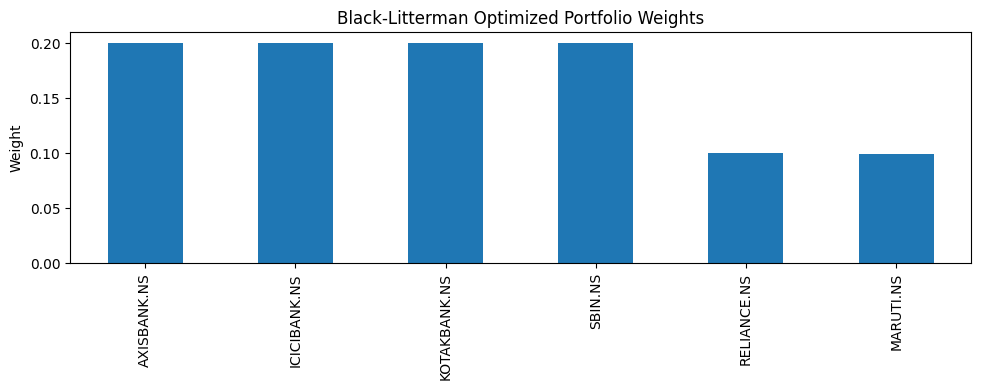

,0
AXISBANK.NS,0.2000
ICICIBANK.NS,0.2000
KOTAKBANK.NS,0.2000
SBIN.NS,0.2000
RELIANCE.NS,0.1005
MARUTI.NS,0.0995


In [ ]:
ef = EfficientFrontier(bl_returns, bl_cov, weight_bounds=(0, MAX_WEIGHT))
raw_weights = ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
weights = ef.clean_weights()

perf = ef.portfolio_performance(verbose=True, risk_free_rate=RISK_FREE_RATE)

weights_df = pd.Series(weights).sort_values(ascending=False)
weights_df = weights_df[weights_df > 0]
weights_df.plot(kind="bar", figsize=(10, 4), title="Black-Litterman Optimized Portfolio Weights")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

weights_df


## 8. Backtest & Risk-Adjusted Performance Evaluation

Holds the optimized weights fixed and evaluates them over the out-of-sample window (`BACKTEST_SPLIT` → `END_DATE`), against an equal-weight portfolio and the Nifty 50 benchmark.

In [ ]:
def performance_stats(returns_series, rf=RISK_FREE_RATE):
    ann_return = (1 + returns_series).prod() ** (252 / len(returns_series)) - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = (ann_return - rf) / ann_vol if ann_vol > 0 else np.nan

    downside = returns_series[returns_series < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) else np.nan
    sortino = (ann_return - rf) / downside_vol if downside_vol else np.nan

    cum = (1 + returns_series).cumprod()
    drawdown = cum / cum.cummax() - 1
    max_dd = drawdown.min()

    return {
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_dd,
    }

backtest_returns = daily_returns.loc[BACKTEST_SPLIT:]
bench_returns = bench_prices.pct_change().dropna().loc[BACKTEST_SPLIT:]

bl_weight_vec = pd.Series(weights).reindex(UNIVERSE).fillna(0)
eq_weight_vec = pd.Series(1 / len(UNIVERSE), index=UNIVERSE)

bl_port_returns = (backtest_returns * bl_weight_vec).sum(axis=1)
eq_port_returns = (backtest_returns * eq_weight_vec).sum(axis=1)

results = pd.DataFrame({
    "Black-Litterman Portfolio": performance_stats(bl_port_returns),
    "Equal-Weight Portfolio": performance_stats(eq_port_returns),
    "Nifty 50 Benchmark": performance_stats(bench_returns),
}).T

# Diversification: Herfindahl-Hirschman Index on weights (lower = more diversified)
hhi_bl = (bl_weight_vec ** 2).sum()
hhi_eq = (eq_weight_vec ** 2).sum()
results["HHI (diversification, lower=better)"] = [hhi_bl, hhi_eq, np.nan]

results


,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,"HHI (diversification, lower=better)"
Black-Litterman Portfolio,0.1628,0.1547,0.5998,0.7980,-0.1197,0.1800
Equal-Weight Portfolio,0.1264,0.1184,0.4763,0.6947,-0.1401,0.0667
Nifty 50 Benchmark,0.0945,0.1297,0.1888,0.2529,-0.1577,NaN


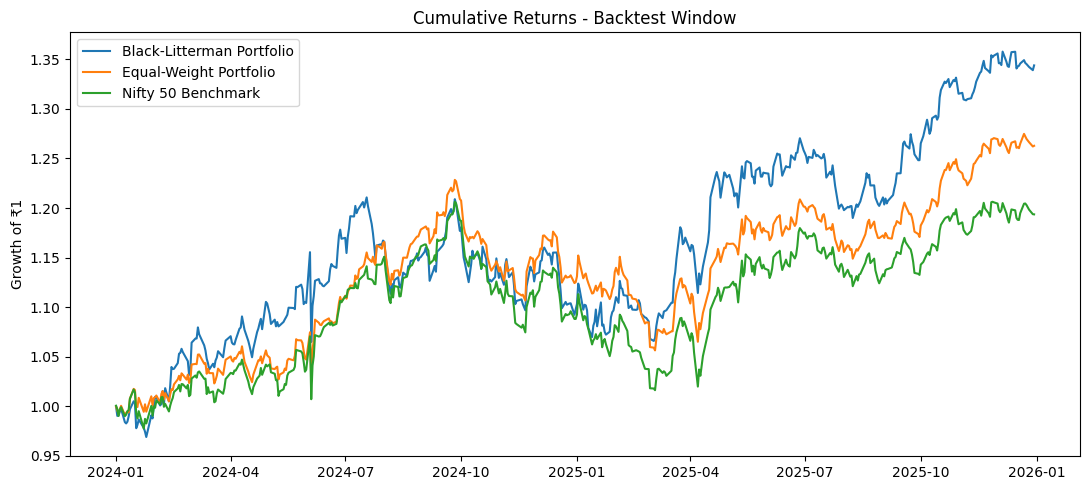

In [ ]:
cum_bl = (1 + bl_port_returns).cumprod()
cum_eq = (1 + eq_port_returns).cumprod()
cum_bench = (1 + bench_returns).cumprod()

plt.figure(figsize=(11, 5))
plt.plot(cum_bl, label="Black-Litterman Portfolio")
plt.plot(cum_eq, label="Equal-Weight Portfolio")
plt.plot(cum_bench, label="Nifty 50 Benchmark")
plt.title("Cumulative Returns - Backtest Window")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.tight_layout()
plt.show()
